In [1]:
#Generate Dataset
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
# Generate synthetic dataset
X, y = make_classification(
n_samples=300,
n_features=6,
n_informative=5,
n_redundant=1,
n_classes=3,
random_state=42
)
# Convert to DataFrame
columns = ['income', 'assets', 'debt', 'cash_flow', 'employees', 'profit_margin']
df = pd.DataFrame(X, columns=columns)
df['vulnerability_status'] = y
df.head()

,income,assets,debt,cash_flow,employees,profit_margin,vulnerability_status
0,0.129046,1.480670,0.191334,3.045718,0.044570,-2.165354,2
1,-1.621786,-1.004943,-3.247289,-0.538076,-1.780639,0.494827,1
2,-0.995168,-1.484321,-0.932939,-1.298973,3.999976,-3.494591,0
3,-0.727494,-1.272801,-0.761114,-1.930491,1.095972,0.194644,1
4,-0.231794,-3.941699,-0.708895,-3.736174,2.127569,-1.261738,2


In [3]:
#Sampling. Take 70% sample for training.
from sklearn.model_selection import train_test_split
X = df.drop('vulnerability_status', axis=1)
y = df['vulnerability_status']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 210
Testing samples: 90


In [4]:
#Feature Scaling. Important before PCA or LDA.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
#PCA (Unsupervised) Reduce from 6 features → 2 principal components.
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.34999    0.21202904]


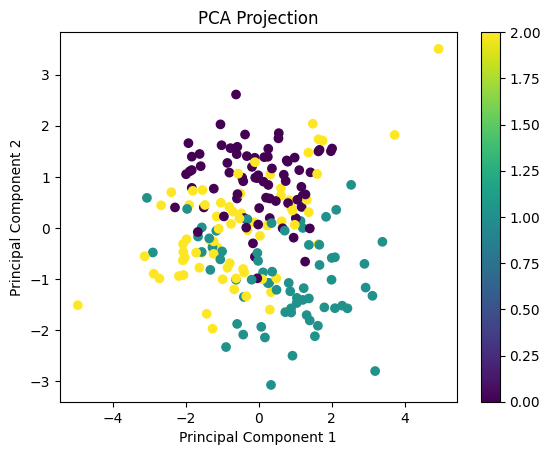

In [6]:
#Visualization
import matplotlib.pyplot as plt
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.colorbar()
plt.show()

In [7]:
#LDA (Supervised) Reduce 6 features → C − 1 = 2 components (since 3 classes)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
print("LDA shape:", X_train_lda.shape)

LDA shape: (210, 2)


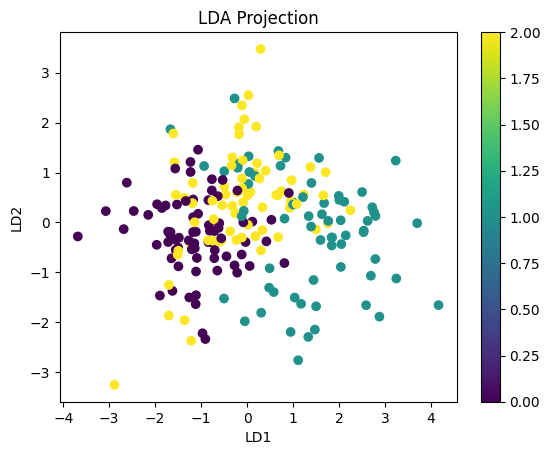

In [8]:
#Visualization
plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='viridis')
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection")
plt.colorbar()
plt.show()

In [9]:
# Compare Classification Accuracy. Train logistic regression: Without Reduction
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_train_scaled, y_train)
y_pred_full = model_full.predict(X_test_scaled)
print("Accuracy (Full Features):", accuracy_score(y_test, y_pred_full))

#With PCA

Accuracy (Full Features): 0.6


In [10]:
X_test_pca = pca.transform(X_test_scaled)
model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
print("Accuracy (PCA):", accuracy_score(y_test, y_pred_pca))

Accuracy (PCA): 0.6222222222222222


In [11]:
#With LDA
X_test_lda = lda.transform(X_test_scaled)
model_lda = LogisticRegression(max_iter=1000)
model_lda.fit(X_train_lda, y_train)
y_pred_lda = model_lda.predict(X_test_lda)
print("Accuracy (LDA):", accuracy_score(y_test, y_pred_lda))

Accuracy (LDA): 0.6111111111111112
